# mlr_pillow_selection.ipynb

In [17]:
import xarray as xr
import os 
import rioxarray
from pyproj import CRS, Transformer
import sys
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd
from rasterio.enums import Resampling
from typing import List, Dict, Tuple, Optional
from datetime import datetime
import time
import importlib
import rioxarray as rxr

In [2]:
sys.path.insert(1, '/home/rossamower/work/aso/snow-ops-streamlit/scripts/')

In [3]:
import metadata as metadata
import plotting as plotting
import preprocessing as preprocessing
import lm_model as lm_model
import postprocessing as postprocessing
import insitu_qa as insitu_qa
import qa_voting as qa_voting

In [4]:
importlib.reload(metadata)
importlib.reload(plotting)
importlib.reload(preprocessing)
importlib.reload(lm_model)
importlib.reload(postprocessing)
importlib.reload(insitu_qa)
importlib.reload(qa_voting)

<module 'qa_voting' from '/home/rossamower/work/aso/snow-ops-streamlit/scripts/qa_voting.py'>

# Inputs

In [5]:
aso_site_name = 'USCASJ'
water_year = 2026

# Functions

## load metadata

In [6]:
def load_aso_metadata(aso_site_name: str,
                  config_dir: str = '/home/rossamower/work/aso/configs/',
                 ):
    cfg = metadata.load_yaml(Path(f"{config_dir}regions/{aso_site_name}.yaml"))
    elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
    start_wy = int(cfg["aso_years"]["start"])
    end_wy = int(cfg["aso_years"]["end"])
    shape_fpath = cfg["data_filepaths"]["aso_shape"]
    demBin_fpath = cfg["data_filepaths"]["aso_demBin"]
    aso_spatial_fpath = cfg["data_filepaths"]["aso_spatial"]
    aso_tseries_fpath = cfg["data_filepaths"]["aso_temporal"]
    uaswe_dir = cfg["data_filepaths"]["uaswe_dir"]
    snowmodel_dir = cfg["data_filepaths"]["snowmodel_dir"]
    snodas_dir = cfg["data_filepaths"]["snodas_dir"]
    insitu_dir = cfg["data_filepaths"]["insitu_dir"]
    mlrPred_dir = cfg["data_filepaths"]["mlrPred_dir"]
    if not os.path.exists(mlrPred_dir): os.makedirs(mlrPred_dir)
    shape_crs = f'EPSG:{cfg["crs"]["epsg"]}'
    return elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir, uaswe_dir, shape_crs, cfg

## Load ASO

In [7]:
def load_aso_data(aso_spatial_fpath: str,
                  aso_tseries_fpath: str,
                  demBin_fpath: str,
                  shape_fpath: str,
                  shape_crs: str,
                 ):
    aso_spatial_ds = xr.open_dataset(aso_spatial_fpath,engine ='netcdf4')
    aso_demBin_ds = xr.open_dataset(demBin_fpath,engine ='netcdf4')
    aso_tseries_ds = xr.open_dataset(aso_tseries_fpath,engine ='netcdf4')
    shape_geog_gdf = gpd.read_file(shape_fpath)
    shape_proj_gdf = shape_geog_gdf.to_crs(shape_crs)

    return aso_spatial_ds, aso_demBin_ds, shape_proj_gdf, aso_tseries_ds

In [14]:
def area_m2_acres(dem_bin,aso_data_1,aso_site_name,applyMask = True):
    """
    Creates dictionary of different elevation bins in acres.
    Input:
      dem_bin: xarray dataset with elevation bins.
      aso_data_1: xarray dataset of aso flights.
      applyMask: python boolean to indicate whether aso common mask is being applied.
    Output:
      area_dict: dictionary of different elevation bins in acres.
    """
    # pull out common mask from aso data.
    mask = (~aso_data_1.aso_swe[-1].isnull()).values

    area_dict = {}
    for i in range(dem_bin.shape[0]):
        if applyMask:
            arr = dem_bin[i].where(mask).values.flatten()
        else:
            arr = dem_bin[i].values.flatten()
        count = len(arr[~np.isnan(arr)])
        m2 = count * 50 * 50
        acres = m2 * 0.000247105
        if aso_site_name in ['USCATM','USCASJ']:
          if dem_bin.elev[i].values == '<7000':
              area_dict['<7k'] = acres
          elif dem_bin.elev[i].values == '7000-8000':
              area_dict['7k-8k'] = acres
          elif dem_bin.elev[i].values == '8000-9000':
              area_dict['8k-9k'] = acres
          elif dem_bin.elev[i].values == '9000-10000':
              area_dict['9k-10k'] = acres
          elif dem_bin.elev[i].values == '10000-11000':
              area_dict['10k-11k'] = acres
          elif dem_bin.elev[i].values == '11000-12000':
              area_dict['11k-12k'] = acres
          elif dem_bin.elev[i].values == '>12000':
              area_dict['>12k'] = acres
          elif dem_bin.elev[i].values == 'total':
              area_dict['Total'] = acres
        elif aso_site_name == 'USCOBR':
          if dem_bin.elev[i].values == '<9000':
              area_dict['<9k'] = acres
          elif dem_bin.elev[i].values == '9000-10000':
              area_dict['9k-10k'] = acres
          elif dem_bin.elev[i].values == '10000-11000':
              area_dict['10k-11k'] = acres
          elif dem_bin.elev[i].values == '11000-12000':
              area_dict['11k-12k'] = acres
          elif dem_bin.elev[i].values == '12000-13000':
              area_dict['12k-13k'] = acres
          elif dem_bin.elev[i].values == '>13000':
              area_dict['>13k'] = acres
          elif dem_bin.elev[i].values == 'total':
              area_dict['Total'] = acres
        elif aso_site_name == 'USCOGE':
          if dem_bin.elev[i].values == '<9000':
              area_dict['<9k'] = acres
          elif dem_bin.elev[i].values == '9000-10000':
              area_dict['9k-10k'] = acres
          elif dem_bin.elev[i].values == '10000-11000':
              area_dict['10k-11k'] = acres
          elif dem_bin.elev[i].values == '11000-12000':
              area_dict['11k-12k'] = acres
          elif dem_bin.elev[i].values == '>12000':
              area_dict['>12k'] = acres
          elif dem_bin.elev[i].values == 'total':
              area_dict['Total'] = acres
    return area_dict

In [15]:
def current_wy_aso(aso_site_name: str,
                   water_year: int,
                   aso_spatial_ds: xr.Dataset,
                   aso_gdf_proj: gpd.GeoDataFrame,
                   area_dict: dict,
                   ):
    aso_eval_dir = f'/home/rossamower/work/aso/data/aso/{aso_site_name}/wy_{water_year}/raw/'
    mean_swe = []
    mean_swe_m = []
    date_lst = []

    if os.path.exists(aso_eval_dir):
        for file in os.listdir(aso_eval_dir):
            print(file)
            da = rxr.open_rasterio(aso_eval_dir + file).squeeze(drop = True)
            print('Initial Shape:', da.shape)
            aso_template = aso_spatial_ds['aso_swe'][0]
            mask = (~aso_template.isnull()).values
            aso_template = aso_template.rio.set_crs(da.rio.crs)
            da_tu_domain = da.rio.clip(aso_gdf_proj.geometry).rio.reproject_match(aso_template).where(mask)
            mean_swe.append(float(da_tu_domain.mean()) * 3.28084 * area_dict['Total'])
            mean_swe_m.append(float(da_tu_domain.mean()) * 1000)
            date_lst.append(f'{file[-12:-8]}-{file[-8:-6]}-{file[-6:-4]}')
    
        mean_swe_arr = np.array(mean_swe)
        date_arr = np.array(date_lst,dtype = np.datetime64)
        return mean_swe_arr, date_arr
    else:
        return None, None

## Misc

In [8]:
def pad_zero(val_str):
    if len(val_str) ==1:
        return '0' + val_str
    else:
        return val_str

def dataset_to_list(ds: xr.Dataset) -> list:
    da_list = []
    for pil in ds.data_vars:
        da = ds[pil]
        da.name = pil
        da_list.append(da)
    return da_list

def snowmodel_swe_fpaths(base_dir,water_yrs,var):
    nc_lst = []
    for wy in water_yrs:
        nc_dir = f'{base_dir}wy_{wy}/netcdf/'
        for file in os.listdir(nc_dir):
            if var in file:
                nc_lst.append(nc_dir + file)
    return sorted(nc_lst)

def timing_vars(obs_data_test_ds: xr.Dataset):
    date_str = str(obs_data_test_ds.time.values[-1])[0:10]
    year_str = date_str[0:4]
    month_str = date_str[5:7]
    day_str = date_str[8:10]
    
    if int(month_str) >= 10:
        wy_str = str(int(year_str) +1)
    else:
        wy_str = year_str
    return year_str, month_str, day_str, wy_str

def get_default_settings():
    user_elevation_interval = -1
    model_num = 0   
    isMean = False
    isCombination = True
    prediction_mm_df = None
    prediction_acreFt_df = None
    prediction_pillow_df = None
    isCombination = True
    user_qa_level = 0
    QA_flag = user_qa_level + 1
    elev_band = user_elevation_interval
    return model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag

# Preprocessing

## Default Settings

In [9]:
model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag = get_default_settings()

## Load Metadata

In [10]:
# load metadata information.
elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir,uaswe_dir,shape_crs,cfg = load_aso_metadata(aso_site_name)

# pillows to exclude from QA.
exclude_pillows = cfg['pillow_api']['exclude_pillows']
elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
start_wy = int(cfg["aso_years"]["start"])
end_wy = int(cfg["aso_years"]["end"])

In [11]:
exclude_pillows

[]

## Load Input Data

In [18]:
# load spatial data.
aso_spatial_ds, dem_bin, shape_proj_gdf, aso_tseries_ds = load_aso_data(aso_spatial_fpath,
                                                                                aso_tseries_fpath,
                                                                                demBin_fpath,
                                                                                shape_fpath,
                                                                                shape_crs)

# area dict.
area_dict = area_m2_acres(dem_bin.dem_bin,aso_spatial_ds,aso_site_name,applyMask = True)

# current wy aso.
current_swe, current_dates = current_wy_aso(aso_site_name,
                                               water_year,
                                               aso_spatial_ds,
                                               shape_proj_gdf,
                                               area_dict)
# obs training.
obs_data_train_ds = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc')
obs_data_train_lst = dataset_to_list(obs_data_train_ds)
# snowmodel 
sm_train_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_train_2017_2025_dowy.zarr', consolidated=False)
sm_test_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_test_2026.zarr', consolidated=False)

# testing raw.
obs_data_test_ds_raw = xr.load_dataset(f'{insitu_dir}raw/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# match times.
obs_data_test_ds_raw = obs_data_test_ds_raw.sel(time = sm_test_ds.time)
obs_data_test_lst_raw = dataset_to_list(obs_data_test_ds_raw)
# testing qa.
obs_data_test_ds = xr.load_dataset(f'{insitu_dir}processed/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# match times.
# obs_data_test_ds = obs_data_test_ds.sel(time = sm_test_ds.time)
obs_data_test_ds = obs_data_test_ds.where(obs_data_test_ds.time.isin(sm_test_ds.time.values),drop = True)
obs_data_test_lst = dataset_to_list(obs_data_test_ds)
# initial pillow list.
pillows = list(obs_data_test_ds.data_vars)
pillows = [i for i in pillows if i not in exclude_pillows]
# get timing variables.
year_str, month_str, day_str, wy_str = timing_vars(obs_data_test_ds)
# load UASWE EARLY data.
uaswe_acreFt_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_acreFt_wy{water_year}.csv')
uaswe_m_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_m_wy{water_year}.csv')
# load UASWE EARLY data.
uaswe_acreFt_provisional_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_acreFt_provisional_wy{water_year}.csv')
uaswe_m_provisional_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_m_provisional_wy{water_year}.csv')
# load SNODAS data.
snodas_acreFt_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_acreFt_wy{water_year}.csv')
snodas_m_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_m_wy{water_year}.csv')
# load SnowModel data.
sm_acreFt_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_acreFt_wy{water_year}.csv')
sm_m_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_m_wy{water_year}.csv')
# convert date columns to datetime.
snodas_acreFt_df['Date'] = pd.to_datetime(snodas_acreFt_df['Date'])
snodas_m_df['Date'] = pd.to_datetime(snodas_m_df['Date'])
uaswe_acreFt_df['Date'] = pd.to_datetime(uaswe_acreFt_df['Date'])
uaswe_m_df['Date'] = pd.to_datetime(uaswe_m_df['Date'])
uaswe_acreFt_provisional_df['Date'] = pd.to_datetime(uaswe_acreFt_provisional_df['Date'])
uaswe_m_provisional_df['Date'] = pd.to_datetime(uaswe_m_provisional_df['Date'])
sm_acreFt_df['Date'] = pd.to_datetime(sm_acreFt_df['Date'])
sm_m_df['Date'] = pd.to_datetime(sm_m_df['Date'])

ASO_50M_SWE_USCASJ_20260127.tif
Initial Shape: (1657, 1931)


In [13]:



importlib.reload(qa_voting)
importlib.reload(insitu_qa)

historic_vals_df = qa_voting.create_qa_tables(obs_data_train_lst, [], isQA=False)

corr_rank = qa_voting.build_corr_rank(
        historic_vals_df,
        use_delta=True,
        min_overlap=200,
        method="r2",
    )
pil_corr = {p: corr_rank.get(p, []) for p in pillows}

df_simple,df_detail = insitu_qa.run_pillow_qa(
    obs_data_test_ds_raw,
    obs_data_test_lst_raw,
    obs_data_train_lst,
    pillows,
    pil_corr,
    train_ds=sm_train_ds,
    test_ds=sm_test_ds,
    corr_rank=corr_rank,
)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25/133
25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50/133
50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75/133
75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100/133
100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125/133
125 126 127 128 129 130 131 132 

In [15]:
df_detail.to_csv('./detail_qa_results_1.csv',index = False)

In [16]:
import pandas as pd

df = pd.read_csv("detail_qa_results_1.csv")
psr = df[(df.pillow=="PSR") & (df.method=="snowmodel") &
         (df.time.between("2026-01-13","2026-01-20"))]

psr[["time","cur_mm","yhat_mm","thr_mm","flag","reason_code","reason_detail"]]


,time,cur_mm,yhat_mm,thr_mm,flag,reason_code,reason_detail
9438,2026-01-13,121.920,273.106389,197.064978,0,OK,NaN
9528,2026-01-14,124.968,272.393357,197.066498,0,OK,NaN
9618,2026-01-15,118.872,274.220649,197.092651,0,OK,NaN
9708,2026-01-16,118.872,295.264764,197.236216,0,OK,NaN
9798,2026-01-17,118.872,298.411461,197.261681,0,OK,NaN
9888,2026-01-18,118.872,299.758321,197.272264,0,OK,NaN
9978,2026-01-19,118.872,299.474003,197.272919,0,OK,NaN


In [ ]:
sm_test_ds.where(sm_test_ds.pil == 'PSR',drop = True).where(sm_test_ds.time >=np.datetime64('2026-01-13'),drop= True).to_dataframe()

## Load Output Data

In [19]:
seasonal_dirs = ["season","accum","melt"]
models = ["COMMON_MASK"]
mlr_tables = []
mlr_identifiers = {}
count = 0
for aso_stack_type in models:
    for seasonal_dir in seasonal_dirs:
        acre_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/acreFt/'
        mm_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/mm/'
        pillow_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/pillows/'

        # read data.
        prediction_acreFt_df = pd.read_csv(f'{acre_path}prediction_acreFt_wy{water_year}_combination.csv')
        prediction_mm_df = pd.read_csv(f'{mm_path}prediction_mm_wy{water_year}_combination.csv')
        prediction_pillows_df = pd.read_csv(f'{pillow_path}prediction_pillows_wy{water_year}_combination.csv')

        # convert date columns to datetime.
        prediction_mm_df['Date'] = pd.to_datetime(prediction_mm_df['Date'])
        prediction_acreFt_df['Date'] = pd.to_datetime(prediction_acreFt_df['Date'])
        prediction_pillows_df['Date'] = pd.to_datetime(prediction_pillows_df['Date'])
            
        mlr_tables.append(prediction_acreFt_df)
        mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'acreFt']
        count += 1 
        mlr_tables.append(prediction_mm_df)
        mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'mm']
        count += 1
        mlr_tables.append(prediction_pillows_df)
        mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'pillows']
        count += 1

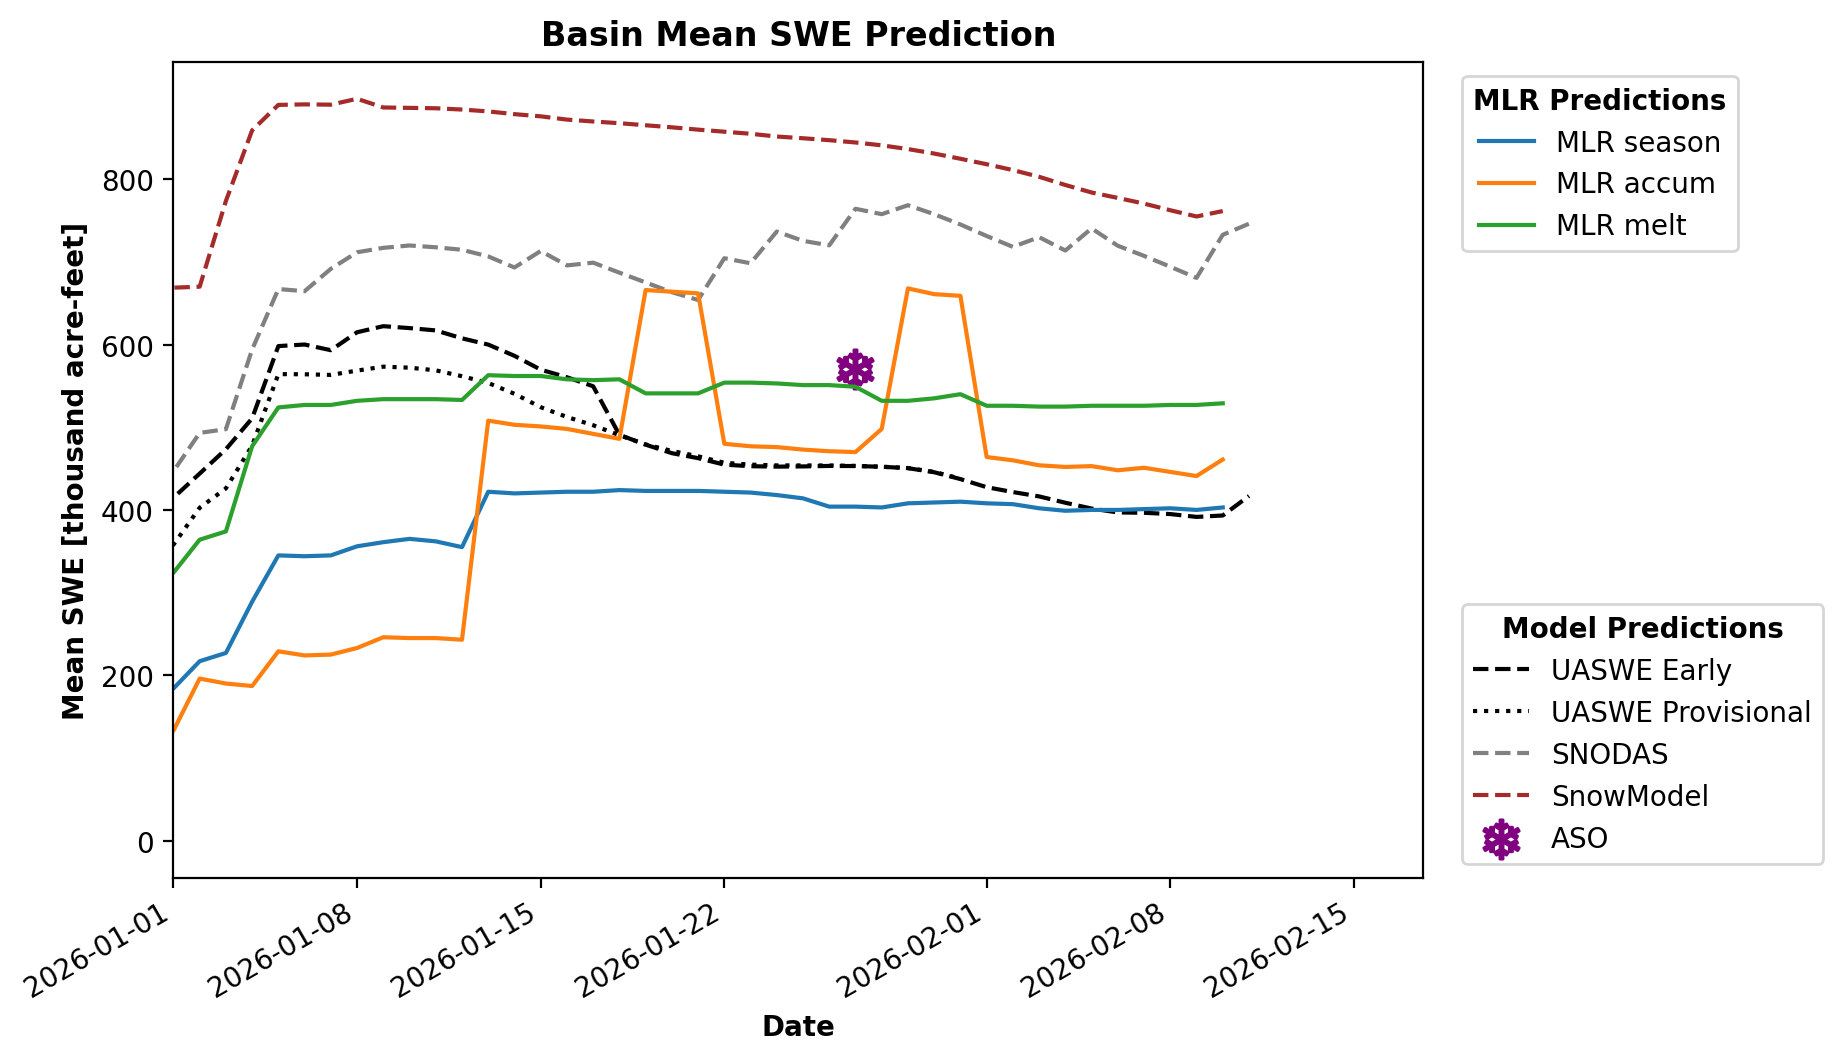

In [20]:
importlib.reload(plotting)
plotting.html_timeseries_plot(mlr_tables,
                                  mlr_identifiers,
                                  uaswe_acreFt_df,
                                  uaswe_acreFt_provisional_df,
                                  snodas_acreFt_df,
                                  sm_acreFt_df,
                                  aso_site_name,
                                  current_dates,
                                  current_swe,
                                  None,
                                  train_infer = 'predict NaNs',
                                  saveFIG = False,
    )

In [ ]:
importlib.reload(plotting)
plotting.html_timeseries_plot(mlr_tables,
                                  mlr_identifiers,
                                  uaswe_acreFt_df,
                                  uaswe_acreFt_provisional_df,
                                  snodas_acreFt_df,
                                  sm_acreFt_df,
                                  aso_site_name,
                                  current_dates,
                                  current_swe,
                                  None,
                                  train_infer = 'predict NaNs',
                                  saveFIG = False,
    )

(<Figure size 1600x800 with 2 Axes>,
 <Axes: title={'center': 'Pillow Selection Across Models Over Time'}, xlabel='Date', ylabel='Pillow'>)

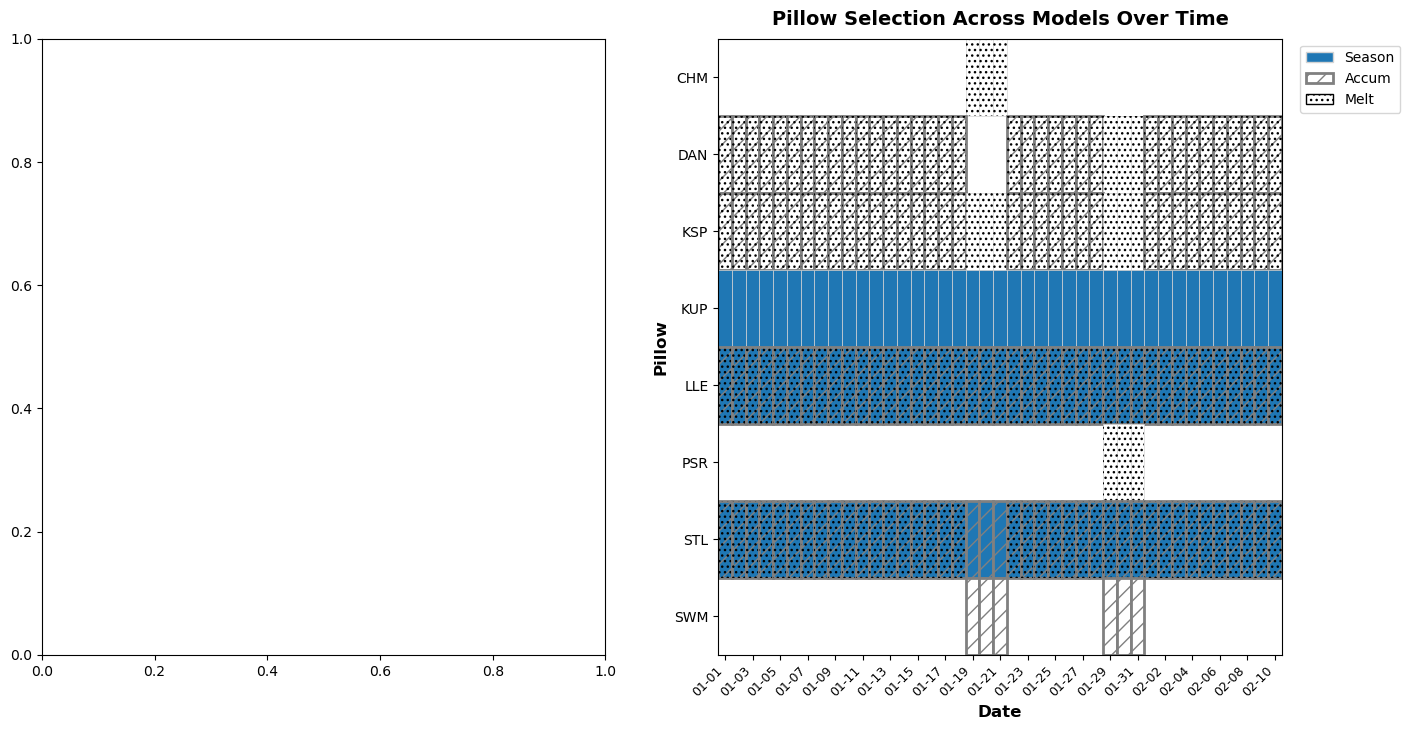

In [41]:
import matplotlib.pyplot as plt
importlib.reload(plotting)
# Example: Unified heatmap showing pillow selections across all models
fig,ax = plt.subplots(1,2,figsize = (16, 8))
plotting.visualize_pillow_selection_heatmap(
    mlr_tables=mlr_tables,
    mlr_identifiers=mlr_identifiers,
    start_date='2026-01-01',
    end_date='2026-02-10',
    train_infer='predict NaNs',
    figsize=(16, 8),
    ax=ax[1],
)

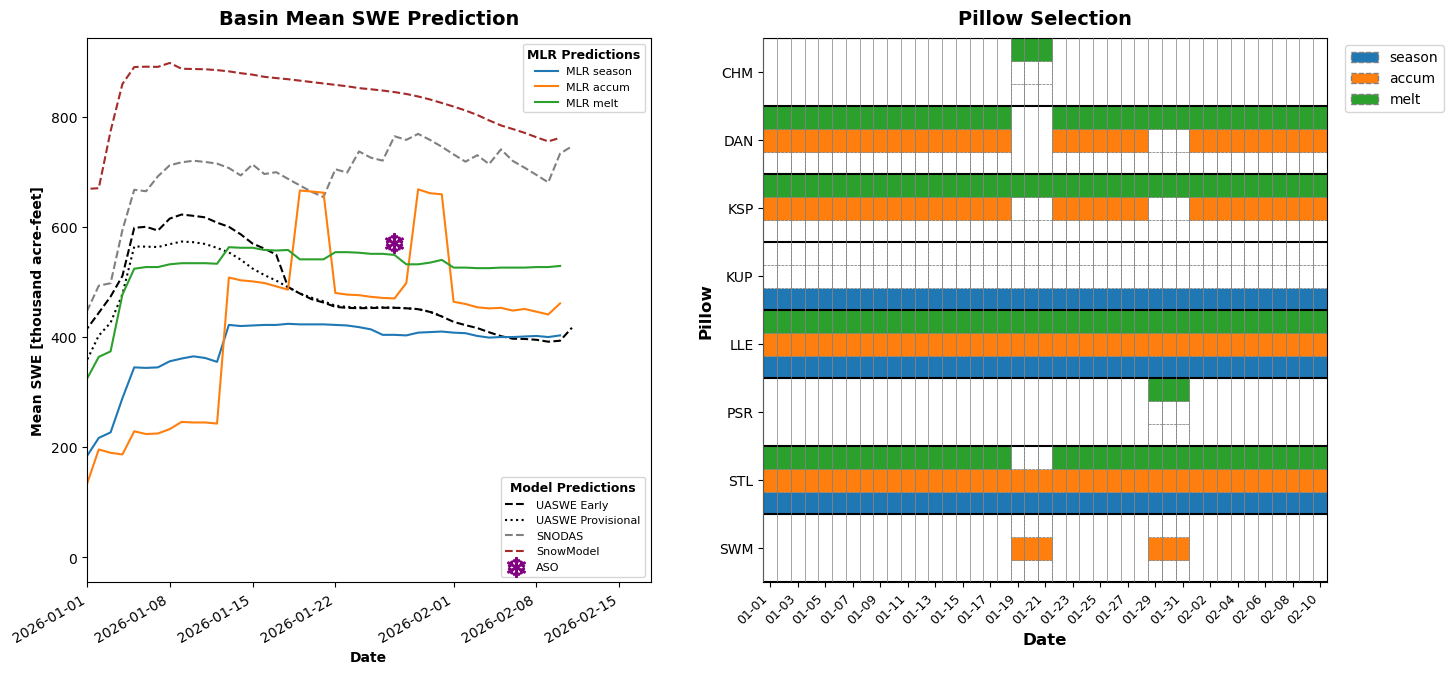

<Figure size 640x480 with 0 Axes>

In [52]:
import matplotlib.pyplot as plt
importlib.reload(plotting)
# Example: Unified heatmap showing pillow selections across all models
fig,ax = plt.subplots(1,2,figsize = (16, 8))

plotting.html_timeseries_plot(mlr_tables,
                                  mlr_identifiers,
                                  uaswe_acreFt_df,
                                  uaswe_acreFt_provisional_df,
                                  snodas_acreFt_df,
                                  sm_acreFt_df,
                                  aso_site_name,
                                  current_dates,
                                  current_swe,
                                  None,
                                  train_infer = 'predict NaNs',
                                  saveFIG = False,
                                  ax=ax[0],
                                  start_date = '2026-01-01',
                                  end_date = None,
    )
plotting.visualize_pillow_selection_heatmap(
    mlr_tables=mlr_tables,
    mlr_identifiers=mlr_identifiers,
    start_date='2026-01-01',
    end_date=None,
    train_infer='predict NaNs',
    figsize=(16, 8),
    ax=ax[1],
)
plt.show()
plt.tight_layout()

In [ ]:
mlr_identifiers

In [ ]:
mlr_tables[2].iloc[-1]

In [ ]:
mlr_tables[5].iloc[-1]

In [ ]:
mlr_tables[8].iloc[-1]

In [ ]:
uaswe_m_df

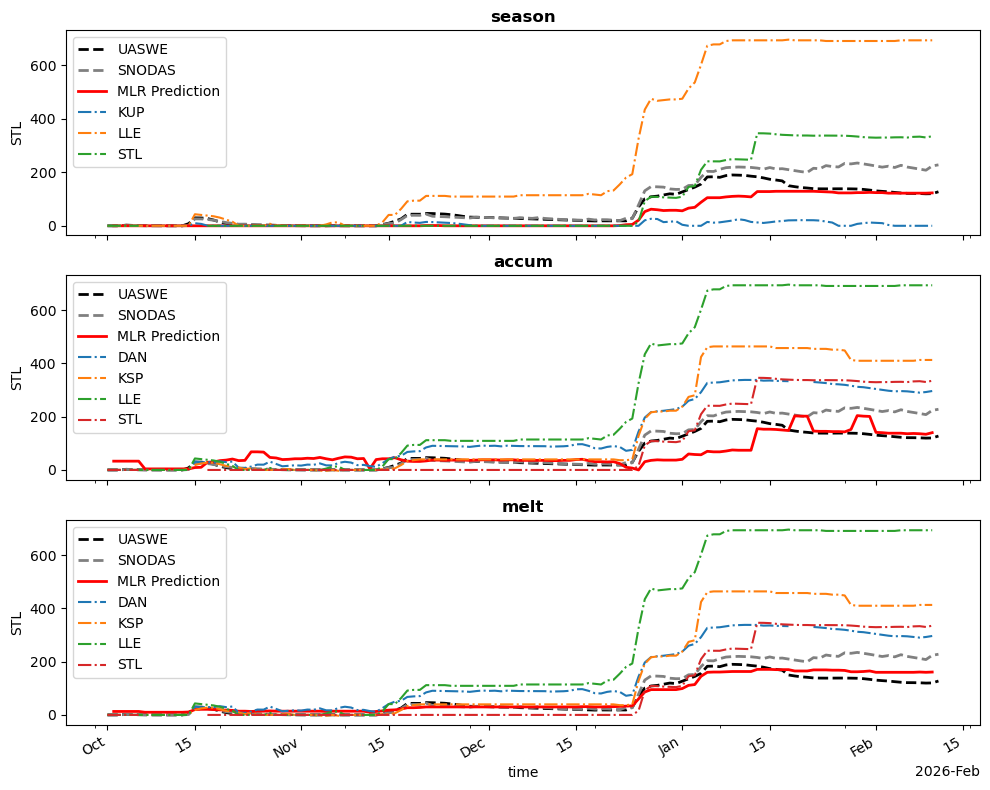

In [21]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(3,1,figsize=(10,8),sharex=True)
# season
ax[0].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[0].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[1][mlr_tables[1]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
for pil in [x.strip() for x in mlr_tables[2].iloc[-1]['Basin'].split(",")]:
    obs_data_test_ds[pil].plot(ax=ax[0],label=pil,linestyle = '-.')
ax[0].legend()
ax[0].set_title(mlr_identifiers[2][1],fontweight = 'bold')
# accum
ax[1].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[1].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[4][mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[1],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
for pil in [x.strip() for x in mlr_tables[5].iloc[-1]['Basin'].split(",")]:
    obs_data_test_ds[pil].plot(ax=ax[1],label=pil,linestyle = '-.')
ax[1].legend()
ax[1].set_title(mlr_identifiers[5][1],fontweight = 'bold')
# melt
ax[2].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[2].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[7][mlr_tables[7]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[2],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
for pil in [x.strip() for x in mlr_tables[8].iloc[-1]['Basin'].split(",")]:
    obs_data_test_ds[pil].plot(ax=ax[2],label=pil,linestyle = '-.')
ax[2].legend()
ax[2].set_title(mlr_identifiers[8][1],fontweight = 'bold')
plt.tight_layout()
plt.show()

0 ['COMMON_MASK', 'season', 'acreFt']
1 ['COMMON_MASK', 'season', 'mm']
2 ['COMMON_MASK', 'season', 'pillows']
3 ['COMMON_MASK', 'accum', 'acreFt']
4 ['COMMON_MASK', 'accum', 'mm']
5 ['COMMON_MASK', 'accum', 'pillows']
6 ['COMMON_MASK', 'melt', 'acreFt']
7 ['COMMON_MASK', 'melt', 'mm']
8 ['COMMON_MASK', 'melt', 'pillows']
1 2


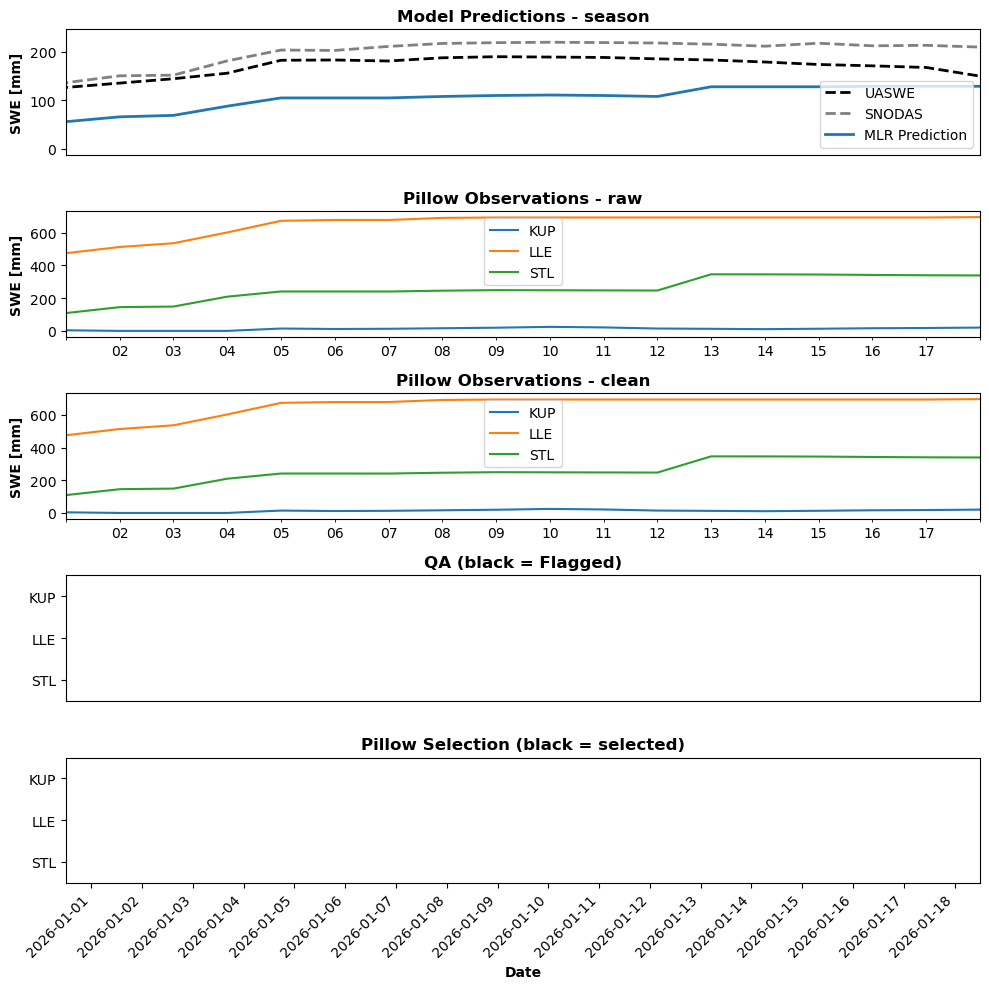

In [22]:
importlib.reload(plotting)
df_pred_slice, df_pil_slice, df_pil_explode, df_pil_mat,diff_arr,nan_arr,diff_mask = plotting.timeseries_pillow_selection(mlr_tables,
                                mlr_identifiers,
                                uaswe_m_df,
                                snodas_m_df,
                                obs_data_test_ds_raw,
                                obs_data_test_ds,
                                start_date = '2026-01-01',
                                end_date = '2026-01-18',
                                model_type = 'season',
                                model_units = 'mm'
                                )

In [ ]:
pil = 'PSR'
out = plotting.plot_pillow_qa_timeline(
        ds_raw=obs_data_test_ds_raw,
        pillow=pil,
        df_simple=df_simple,
        ds_qa=None,
        start='2026-01-01',
        end='2026-01-18',
        saveFIG = False,
        figDIR = None
    )

In [ ]:
    # static
__ = plotting.plot_qa_method_diagnostics(
        ds_raw=obs_data_test_ds_raw,
        df_detail=df_detail,
        pillow=pil,
        ds_qa=None,               # or None
        qa_method="static",
        pil_corr=pil_corr,
        top_k=5,
        start="2026-01-01",
        end='2026-01-18',
        majority_df_simple=df_simple,   # optional
        saveFIG = False,
        figDIR = None,
    )

    # voting
__ = plotting.plot_qa_method_diagnostics(
        ds_raw=obs_data_test_ds_raw,
        df_detail=df_detail,
        pillow=pil,
        ds_qa=None, 
        qa_method="voting",
        start="2026-01-01",
        end='2026-01-18',
        majority_df_simple=df_simple,
        saveFIG = False,
        figDIR = None,
    )

    # snowmodel (+ show best/second/third from test_ds)
__ = plotting.plot_qa_method_diagnostics(
        ds_raw=obs_data_test_ds_raw,
        df_detail=df_detail,
        pillow=pil,
        ds_qa=None,
        qa_method="snowmodel",
        pred_ds=sm_test_ds,               # <<< optional; draws swed_best/second/third
        start="2026-01-01",
        end='2026-01-18',
        majority_df_simple=df_simple,
        saveFIG = False,
        figDIR = None,
    )

In [ ]:
obs_data_test_ds_raw['PSR'][-1]

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(nan_arr[::-1,:],aspect="auto",interpolation='nearest',cmap = 'viridis')

In [ ]:
df_pred_slice = mlr_tables[4][(mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs') &  \
              (mlr_tables[4]['Date'] < np.datetime64('2025-11-15'))]

In [ ]:
df_pil_slice = mlr_tables[5][(mlr_tables[5]['Training Infer NaNs'] == 'predict NaNs') &  \
              (mlr_tables[5]['Date'] < np.datetime64('2025-11-15'))][['Date','Basin']]

In [ ]:
fig,ax = plt.subplots(3,1,figsize=(10,8),sharex=True)
# accum
ax[0].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[0].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[4][mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
# for pil in [x.strip() for x in mlr_tables[5].iloc[-1]['Basin'].split(",")]:
#     obs_data_test_ds[pil].plot(ax=ax[0],label=pil,linestyle = '-.')
ax[0].legend()
ax[0].set_title(mlr_identifiers[5][1],fontweight = 'bold')
ax[0].set_xlim(np.datetime64('2025-10-01'),np.datetime64('2025-11-15'))

obs_data_test_ds_raw['LLE'].plot(ax=ax[1],label='LLE',linestyle = '-')
obs_data_test_ds_raw['STL'].plot(ax=ax[1],label='STL',linestyle = '-')
obs_data_test_ds_raw['SWM'].plot(ax=ax[1],label='SWM',linestyle = '-')
obs_data_test_ds_raw['FLV'].plot(ax=ax[1],label='FLV',linestyle = '-')
ax[1].legend()
ax[1].set_ylim(-10,200)
ax[1].set_title('raw pillows',fontweight = 'bold')


obs_data_test_ds['LLE'].plot(ax=ax[2],label='LLE',linestyle = '-')
obs_data_test_ds['STL'].plot(ax=ax[2],label='STL',linestyle = '-')
obs_data_test_ds['SWM'].plot(ax=ax[2],label='SWM',linestyle = '-')
obs_data_test_ds['FLV'].plot(ax=ax[2],label='FLV',linestyle = '-')
ax[2].legend()
ax[2].set_ylim(-10,200)
ax[2].set_title('clean pillows',fontweight = 'bold')

In [ ]:
df_pil_slice

In [ ]:
obs_data_test_ds_raw.where(obs_data_test_ds_raw.time < np.datetime64('2025-10-01'))

In [ ]:
raw_df = obs_data_test_ds_raw.where(obs_data_test_ds_raw.time > np.datetime64('2025-10-01'),drop = True) \
                    .where(obs_data_test_ds_raw.time < np.datetime64('2025-11-15'),drop = True) \
                   [['LLE','STL','SWM','FLV']].to_dataframe()

test_df = obs_data_test_ds.where(obs_data_test_ds.time > np.datetime64('2025-10-01'),drop = True) \
                    .where(obs_data_test_ds.time < np.datetime64('2025-11-15'),drop = True) \
                   [['LLE','STL','SWM','FLV']].to_dataframe()

In [ ]:
diff_mask = ~(
    (raw_df == test_df) |
    (raw_df.isna() & test_df.isna())
)
diff_mask

nan_mask = ~raw_df.isna()
nan_mask

In [ ]:
df = nan_mask.copy()

# Ensure datetime + sorted
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Convert to numeric for plotting:
#   True -> 1, False -> 0, NaN -> np.nan (so it can be a separate color if you want)
arr = df.astype("float").to_numpy().T   # transpose so pillows are rows, time is cols

fig, ax = plt.subplots(figsize=(12, 3.5))

im = ax.imshow(
    arr,
    aspect="auto",
    interpolation="nearest",
    cmap = 'binary'
)

ax.set_xlabel("Date")
ax.set_ylabel("Pillow")

# Y ticks = pillows
ax.set_yticks(np.arange(df.shape[1]))
ax.set_yticklabels(df.columns)
# X ticks = dates (downsample if many)
step = max(1, len(df.index) // 12)  # ~12 ticks
xt = np.arange(0, len(df.index), step)
ax.set_xticks(xt)
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in df.index[xt]], rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
# Ensure datetime
df = df_pil_slice.copy()
df["Date"] = pd.to_datetime(df["Date"])

# Split basin strings into lists
df["Pillow"] = df["Basin"].str.split(r"\s*,\s*")

# Explode to long format
df_long = df.explode("Pillow")[["Date", "Pillow"]]
# Create binary presence matrix
mat = (
    df_long
    .assign(value=1)
    .pivot(index="Pillow", columns="Date", values="value")
    .fillna(0)
    .sort_index()
)
fig,ax = plt.subplots(2,1,figsize=(10,8),sharex=False)
ax[0].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[0].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[4][mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
# for pil in [x.strip() for x in mlr_tables[5].iloc[-1]['Basin'].split(",")]:
#     obs_data_test_ds[pil].plot(ax=ax[0],label=pil,linestyle = '-.')
ax[0].legend()
ax[0].set_title(mlr_identifiers[5][1],fontweight = 'bold')
ax[0].set_xlim(np.datetime64('2025-10-01'),np.datetime64('2025-11-14'))
ax[0].set_xticks([])
ax[0].set_xlabel('')

im = ax[1].imshow(
    mat.values,
    aspect="auto",
    interpolation="nearest",
    cmap = 'binary',
)

# Axis labels
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Pillow")

# Ticks
ax[1].set_yticks(range(len(mat.index)))
ax[1].set_yticklabels(mat.index)

ax[1].set_xticks(range(len(mat.columns)))
ax[1].set_xticklabels(
    [d.strftime("%Y-%m-%d") for d in mat.columns],
    rotation=45,
    ha="right"
)

ax[1].set_title('Pillow Selection (black = selected)',fontweight = 'bold')
plt.tight_layout()
plt.show()

In [ ]:
[d.strftime("%Y-%m-%d") for d in mat.columns]

In [ ]:
def visualize_pillow_selection_across_models(
    mlr_tables: list,
    mlr_identifiers: dict,
    obs_data_test_ds: xr.Dataset,
    uaswe_m_df: pd.DataFrame,
    snodas_m_df: pd.DataFrame,
    start_date: str = None,
    end_date: str = None,
    train_infer: str = 'predict NaNs',
    figsize: tuple = (14, 12)
):
    """
    Visualize pillow selections across season, accum, and melt models.
    
    Parameters:
    -----------
    mlr_tables : list
        List of MLR prediction dataframes
    mlr_identifiers : dict
        Dictionary mapping indices to [aso_stack_type, seasonal_dir, data_type]
    obs_data_test_ds : xr.Dataset
        Test observation dataset
    uaswe_m_df : pd.DataFrame
        UASWE data in meters
    snodas_m_df : pd.DataFrame
        SNODAS data in meters
    start_date : str, optional
        Start date for visualization (format: 'YYYY-MM-DD')
    end_date : str, optional
        End date for visualization (format: 'YYYY-MM-DD')
    train_infer : str
        Filter for 'Training Infer NaNs' column
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    import matplotlib.dates as mdates
    
    # Find indices for each model type
    model_indices = {}
    for idx, (stack_type, seasonal_dir, data_type) in mlr_identifiers.items():
        if seasonal_dir in ['season', 'accum', 'melt']:
            if seasonal_dir not in model_indices:
                model_indices[seasonal_dir] = {}
            if data_type == 'mm':
                model_indices[seasonal_dir]['mm'] = idx
            elif data_type == 'pillows':
                model_indices[seasonal_dir]['pillows'] = idx
    
    # Create figure with 3 rows x 2 columns
    fig, axes = plt.subplots(3, 2, figsize=figsize, 
                             gridspec_kw={'width_ratios': [3, 1]})
    
    model_order = ['season', 'accum', 'melt']
    colors = ['C0', 'C1', 'C2']
    
    for row_idx, (model_type, color) in enumerate(zip(model_order, colors)):
        if model_type not in model_indices:
            continue
            
        mm_idx = model_indices[model_type].get('mm')
        pil_idx = model_indices[model_type].get('pillows')
        
        if mm_idx is None or pil_idx is None:
            continue
        
        # Left panel: MLR predictions with selected pillows
        ax_pred = axes[row_idx, 0]
        
        # Plot base models
        ax_pred.plot(uaswe_m_df['Date'], uaswe_m_df['total']*1000, 
                    label='UASWE', color='black', linewidth=2, linestyle='--')
        ax_pred.plot(snodas_m_df['Date'], snodas_m_df['total']*1000, 
                    label='SNODAS', color='gray', linewidth=2, linestyle='--')
        
        # Plot MLR prediction
        pred_df = mlr_tables[mm_idx][mlr_tables[mm_idx]['Training Infer NaNs'] == train_infer].copy()
        if start_date:
            pred_df = pred_df[pred_df['Date'] >= np.datetime64(start_date)]
        if end_date:
            pred_df = pred_df[pred_df['Date'] <= np.datetime64(end_date)]
        
        pred_df.plot(ax=ax_pred, x='Date', y='Basin', color=color, 
                    linewidth=2, label='MLR Prediction')
        
        # Get selected pillows from pillow table
        pil_df = mlr_tables[pil_idx][mlr_tables[pil_idx]['Training Infer NaNs'] == train_infer].copy()
        if start_date:
            pil_df = pil_df[pil_df['Date'] >= np.datetime64(start_date)]
        if end_date:
            pil_df = pil_df[pil_df['Date'] <= np.datetime64(end_date)]
        
        if len(pil_df) > 0:
            selected_pillows = [x.strip() for x in pil_df.iloc[-1]['Basin'].split(",")]
            for pil in selected_pillows:
                if pil in obs_data_test_ds:
                    obs_data_test_ds[pil].plot(ax=ax_pred, label=pil, linestyle='-.', alpha=0.7)
        
        ax_pred.legend(loc='upper left', fontsize=8, ncol=2)
        ax_pred.set_title(f'{model_type.capitalize()} Model', fontweight='bold')
        ax_pred.set_ylabel('SWE [mm]', fontweight='bold')
        
        if start_date and end_date:
            ax_pred.set_xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))
        
        # Use manual date formatting to avoid matplotlib's automatic date formatter issues
        import matplotlib.dates as mdates
        ax_pred.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax_pred.xaxis.set_major_locator(mdates.AutoDateLocator())
        
        if row_idx < 2:
            ax_pred.set_xlabel('')
            ax_pred.tick_params(axis='x', labelbottom=False)
        else:
            ax_pred.set_xlabel('Date', fontweight='bold')
            plt.setp(ax_pred.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # Right panel: Pillow selection matrix
        ax_matrix = axes[row_idx, 1]
        
        # Create pillow selection matrix
        df_pil = pil_df[['Date', 'Basin']].copy()
        df_pil["Date"] = pd.to_datetime(df_pil["Date"])
        df_pil["Pillow"] = df_pil["Basin"].str.split(r"\s*,\s*")
        
        # Explode to long format
        df_long = df_pil.explode("Pillow")[["Date", "Pillow"]]
        
        # Create binary presence matrix
        if len(df_long) > 0:
            mat = (
                df_long
                .assign(value=1)
                .pivot(index="Pillow", columns="Date", values="value")
                .fillna(0)
                .sort_index()
            )
            
            im = ax_matrix.imshow(
                mat.values,
                aspect="auto",
                interpolation="nearest",
                cmap='binary',
            )
            
            ax_matrix.set_yticks(range(len(mat.index)))
            ax_matrix.set_yticklabels(mat.index, fontsize=8)
            
            # Set x-ticks with dates - convert timestamps to strings first to avoid date formatter issues
            step = max(1, len(mat.columns) // 5)
            xticks = list(range(0, len(mat.columns), step))
            ax_matrix.set_xticks(xticks)
            # Convert timestamps to strings immediately to avoid matplotlib date formatting issues
            date_labels = [pd.Timestamp(mat.columns[i]).strftime("%m-%d") for i in xticks]
            ax_matrix.set_xticklabels(
                date_labels,
                rotation=45,
                ha="right",
                fontsize=8
            )
        else:
            ax_matrix.text(0.5, 0.5, 'No data', ha='center', va='center',
                          transform=ax_matrix.transAxes)
            ax_matrix.set_xticks([])
            ax_matrix.set_yticks([])
        
        ax_matrix.set_title('Pillow Selection', fontweight='bold', fontsize=10)
        ax_matrix.set_ylabel('Pillow', fontweight='bold', fontsize=8)
        
        if row_idx < 2:
            ax_matrix.set_xlabel('')
        else:
            ax_matrix.set_xlabel('Date', fontweight='bold')
    
    try:
        plt.tight_layout()
    except Exception as e:
        print(f"Warning: tight_layout failed: {e}")
        pass
    return fig, axes

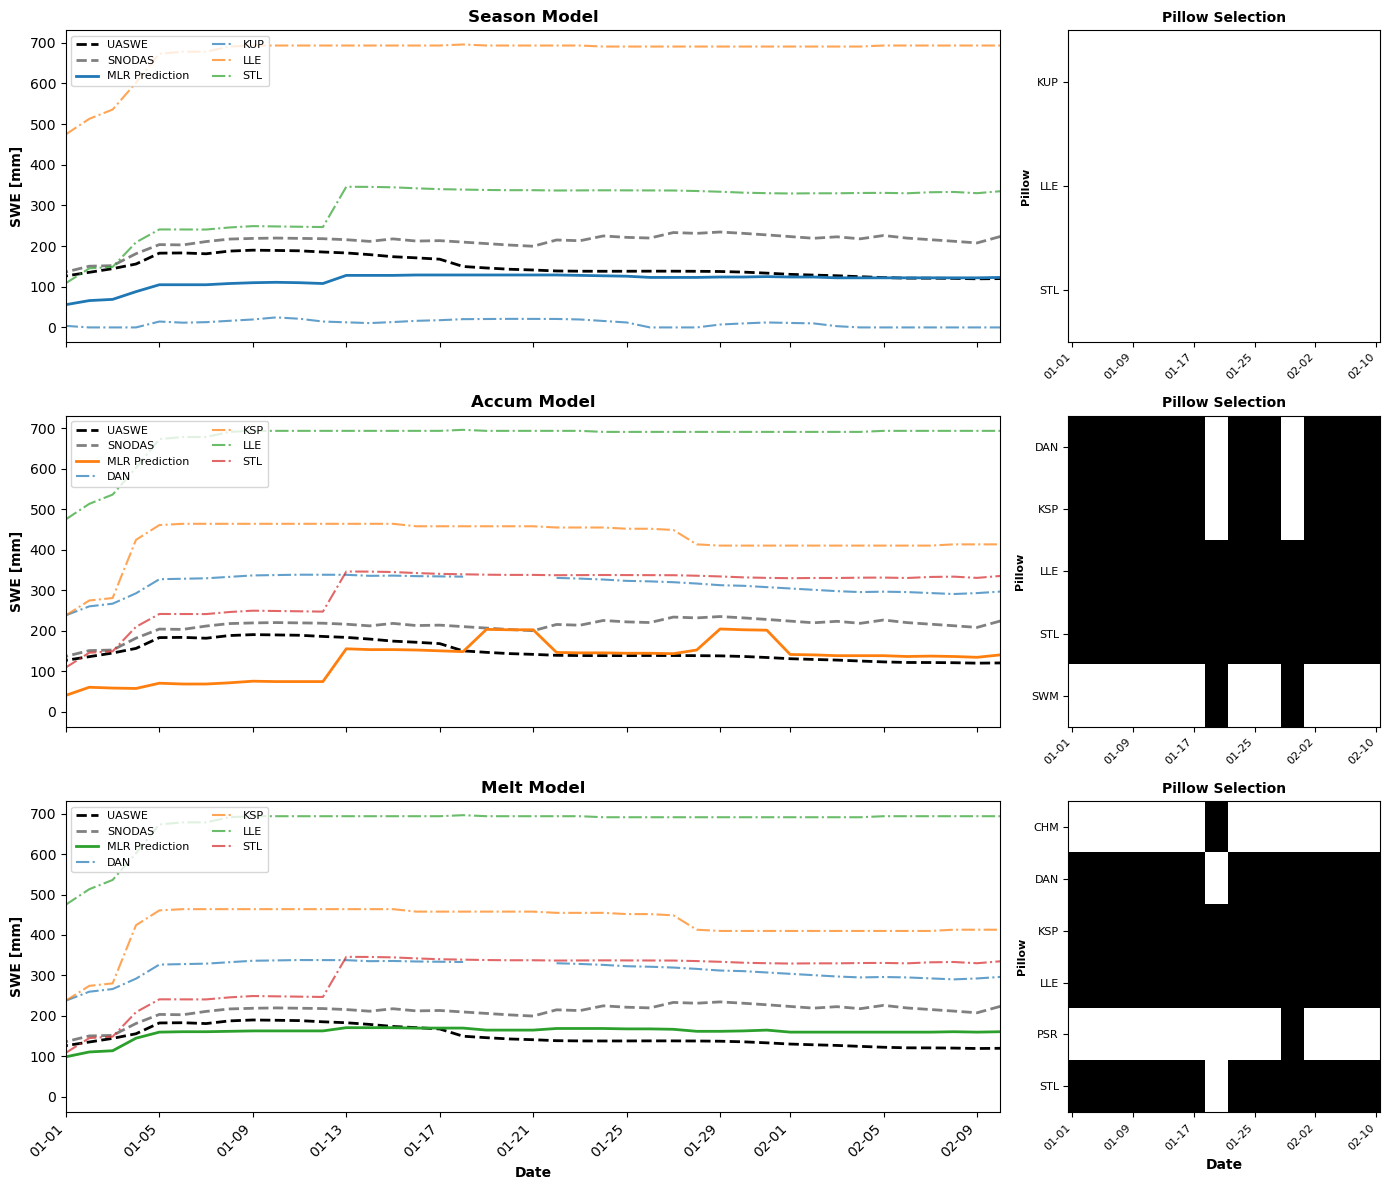

In [27]:
# Example: Visualize pillow selections across all three models
fig, axes = visualize_pillow_selection_across_models(
    mlr_tables=mlr_tables,
    mlr_identifiers=mlr_identifiers,
    obs_data_test_ds=obs_data_test_ds,
    uaswe_m_df=uaswe_m_df,
    snodas_m_df=snodas_m_df,
    start_date='2026-01-01',
    end_date='2026-02-10',
    train_infer='predict NaNs',
    figsize=(14, 12)
)

In [38]:
def visualize_pillow_selection_heatmap(
    mlr_tables: list,
    mlr_identifiers: dict,
    start_date: str = None,
    end_date: str = None,
    train_infer: str = 'predict NaNs',
    figsize: tuple = (16, 8)
):
    """
    Create a unified heatmap showing which pillows were selected by which models across time.
    
    Parameters:
    -----------
    mlr_tables : list
        List of MLR prediction dataframes
    mlr_identifiers : dict
        Dictionary mapping indices to [aso_stack_type, seasonal_dir, data_type]
    start_date : str, optional
        Start date for visualization (format: 'YYYY-MM-DD')
    end_date : str, optional
        End date for visualization (format: 'YYYY-MM-DD')
    train_infer : str
        Filter for 'Training Infer NaNs' column
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    import matplotlib.patches as mpatches
    
    # Find indices for each model type (pillows only)
    model_indices = {}
    for idx, (stack_type, seasonal_dir, data_type) in mlr_identifiers.items():
        if seasonal_dir in ['season', 'accum', 'melt'] and data_type == 'pillows':
            model_indices[seasonal_dir] = idx
    
    model_order = ['season', 'accum', 'melt']
    
    # Collect all pillow selections for each model
    all_selections = {}
    all_dates = set()
    all_pillows = set()
    
    for model_type in model_order:
        if model_type not in model_indices:
            continue
        
        pil_idx = model_indices[model_type]
        pil_df = mlr_tables[pil_idx][mlr_tables[pil_idx]['Training Infer NaNs'] == train_infer].copy()
        
        if start_date:
            pil_df = pil_df[pil_df['Date'] >= np.datetime64(start_date)]
        if end_date:
            pil_df = pil_df[pil_df['Date'] <= np.datetime64(end_date)]
        
        # Parse pillow selections
        df_pil = pil_df[['Date', 'Basin']].copy()
        df_pil["Date"] = pd.to_datetime(df_pil["Date"])
        df_pil["Pillow"] = df_pil["Basin"].str.split(r"\s*,\s*")
        
        # Explode to long format
        df_long = df_pil.explode("Pillow")[["Date", "Pillow"]]
        
        if len(df_long) > 0:
            all_selections[model_type] = df_long
            all_dates.update(df_long['Date'].unique())
            all_pillows.update(df_long['Pillow'].unique())
    
    # Create sorted lists
    sorted_dates = sorted(list(all_dates))
    sorted_pillows = sorted(list(all_pillows))
    
    # Create a 2D matrix: pillows x dates
    # Values: 0=none, 1=season, 2=accum, 3=melt, 4=season+accum, 5=season+melt, 6=accum+melt, 7=all three
    n_pillows = len(sorted_pillows)
    n_dates = len(sorted_dates)
    
    # Model encoding
    model_encoding = {'season': 1, 'accum': 2, 'melt': 4}
    
    # Initialize matrix
    selection_matrix = np.zeros((n_pillows, n_dates), dtype=int)
    
    # Fill matrix with bitwise OR for overlapping selections
    for model_type, df_long in all_selections.items():
        model_val = model_encoding[model_type]
        for _, row in df_long.iterrows():
            pil_idx = sorted_pillows.index(row['Pillow'])
            date_idx = sorted_dates.index(row['Date'])
            selection_matrix[pil_idx, date_idx] |= model_val
    
    # Define colors for each model
    color_season = '#1f77b4'  # blue
    color_white = 'white'     # white background for non-season
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw rectangles with colors and hatching patterns
    # We'll iterate through the matrix and draw patches for each cell
    from matplotlib.patches import Rectangle
    
    for i in range(n_pillows):
        for j in range(n_dates):
            val = selection_matrix[i, j]
            if val == 0:
                continue  # Skip empty cells
            
            # Determine base color and hatching
            # Season=1, Accum=2, Melt=4
            has_season = (val & 1) > 0
            has_accum = (val & 2) > 0
            has_melt = (val & 4) > 0
            
            # Determine base color
            if has_season:
                facecolor = color_season
            else:
                facecolor = color_white
            
            # Draw base rectangle (no hatching)
            rect = Rectangle((j - 0.5, i - 0.5), 1, 1, 
                           facecolor=facecolor, 
                           edgecolor='lightgray',
                           linewidth=0.5)
            ax.add_patch(rect)
            
            # Add accum hatching with gray color if present
            if has_accum:
                rect_accum = Rectangle((j - 0.5, i - 0.5), 1, 1, 
                               facecolor='none',  # transparent
                               edgecolor='gray',
                               hatch='//',
                               linewidth=2)
                ax.add_patch(rect_accum)
            
            # Add melt hatching with black color if present
            if has_melt:
                rect_melt = Rectangle((j - 0.5, i - 0.5), 1, 1, 
                               facecolor='none',  # transparent
                               edgecolor='black',
                               hatch='...',
                               linewidth=0)
                ax.add_patch(rect_melt)
    
    # Set axis limits and appearance
    ax.set_xlim(-0.5, n_dates - 0.5)
    ax.set_ylim(-0.5, n_pillows - 0.5)
    ax.invert_yaxis()  # Invert y-axis so first pillow is at top
    
    # Set y-axis (pillows)
    ax.set_yticks(range(n_pillows))
    ax.set_yticklabels(sorted_pillows, fontsize=10)
    ax.set_ylabel('Pillow', fontweight='bold', fontsize=12)
    
    # Set x-axis (dates)
    step = max(1, n_dates // 20)  # Show ~20 tick labels
    xticks = list(range(0, n_dates, step))
    ax.set_xticks(xticks)
    date_labels = [pd.Timestamp(sorted_dates[i]).strftime("%m-%d") for i in xticks]
    ax.set_xticklabels(date_labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Date', fontweight='bold', fontsize=12)
    
    # Create legend with hatching patterns
    legend_elements = [
        mpatches.Patch(facecolor=color_season, edgecolor='lightgray', label='Season'),
        mpatches.Patch(facecolor='white', edgecolor='gray', hatch='//', linewidth=2, label='Accum'),
        mpatches.Patch(facecolor='white', edgecolor='black', hatch='...', label='Melt'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
              fontsize=10, frameon=True)
    
    ax.set_title('Pillow Selection Across Models Over Time', fontweight='bold', fontsize=14, pad=10)
    
    plt.tight_layout()
    
    return fig, ax

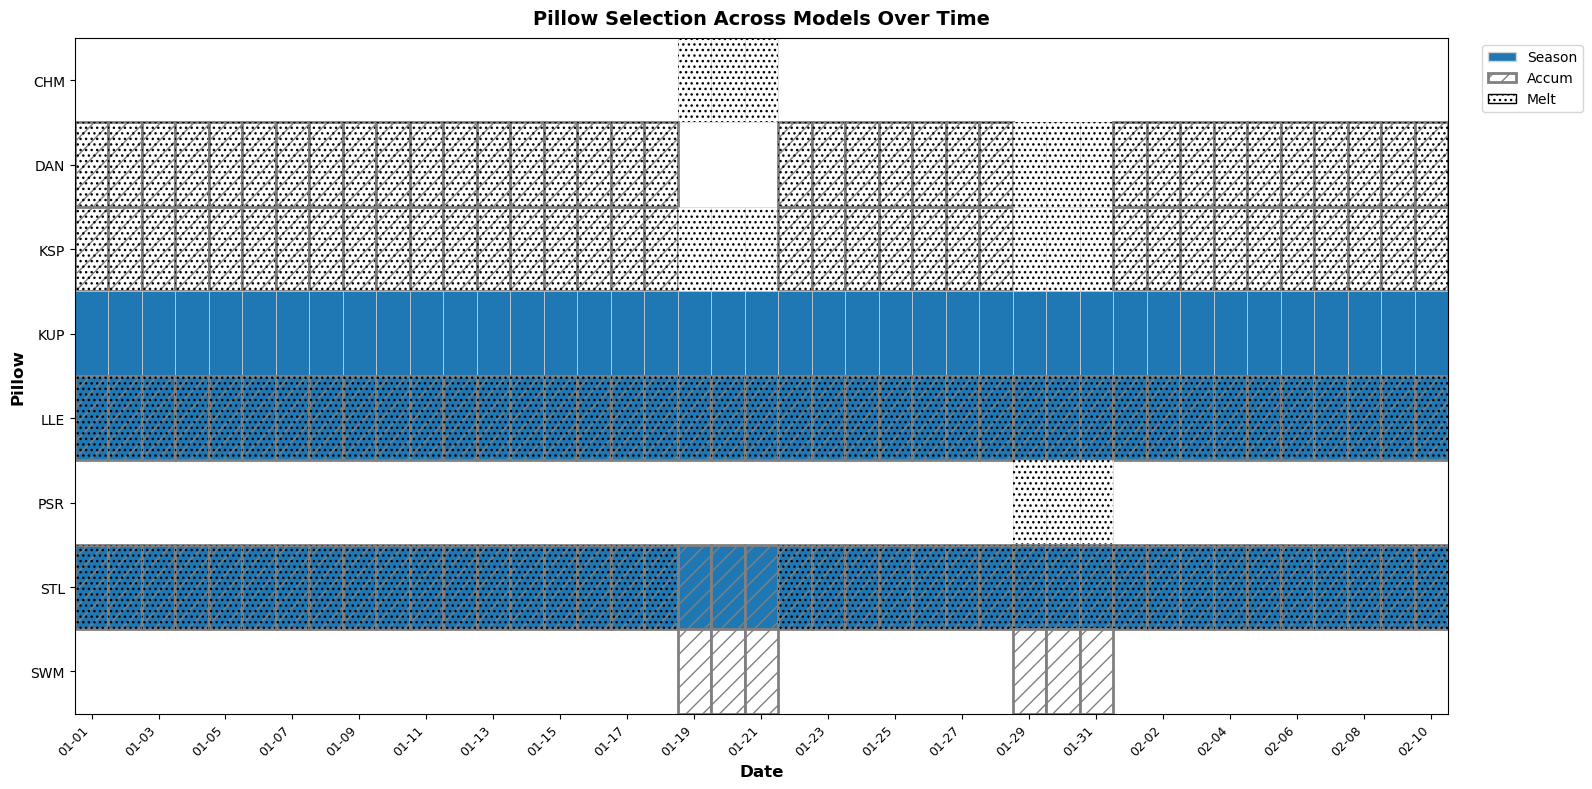

In [ ]:
# Example: Unified heatmap showing pillow selections across all models
fig, ax = visualize_pillow_selection_heatmap(
    mlr_tables=mlr_tables,
    mlr_identifiers=mlr_identifiers,
    start_date='2026-01-01',
    end_date='2026-02-10',
    train_infer='predict NaNs',
    figsize=(16, 8)
)


In [ ]:
importlib.reload(plotting)
plotting.html_timeseries_plot(mlr_tables,
                                  mlr_identifiers,
                                  uaswe_acreFt_df,
                                  uaswe_acreFt_provisional_df,
                                  snodas_acreFt_df,
                                  sm_acreFt_df,
                                  aso_site_name,
                                  current_dates,
                                  current_swe,
                                  None,
                                  train_infer = 'predict NaNs',
                                  saveFIG = False,
    )